# TestGiuse Phasor Workflow


### This Notebook's Operations

This workflow starts from `FILENAME_INPUT`, creates a calibrated source file, then appends phasor products into the same output file.

1. `FILENAME_INPUT` -> calibration -> `FILENAME_OUTPUT`
2. `FILENAME_OUTPUT` -> `phasor` with `mode="append"` -> `FILENAME_OUTPUT`

The exported file keeps the calibrated input content and adds the phasor lifetime products under `/output/phasor`.

Calibrate channel timing, compute corrected phasor maps, and visualize lifetime maps.


In [16]:
FILE_REFERENCE = '/mnt/DATA/Mixed Data/Giuse2/RefFarRed_DFD.h5'
FILENAME_INPUT = '/mnt/DATA/Mixed Data/Giuse2/Test_01_small_DFD.h5'
DATA_KEY = ("data", "data_channels_extra")

TAU_REF = None
REFERENCE_TYPE = 'ref'
FIT_MODE = "model_shift"
FIT_TYPE = "likelihood"
LASER_FREQ_MHZ = None
LASER_PERIOD_NS = None
CHANNEL_SKEW_SOURCE = 'ref'
OVERWRITE = True

FILENAME_OUTPUT = FILENAME_INPUT.replace(".h5", "_phasor_workflow.h5")

print(f"Input file (ref): {FILE_REFERENCE}")
print(f"Input file (data): {FILENAME_INPUT}")
print(f"Calibration and output products to: {FILENAME_OUTPUT}")


Input file (ref): /mnt/DATA/Mixed Data/Giuse2/RefFarRed_DFD.h5
Input file (data): /mnt/DATA/Mixed Data/Giuse2/Test_01_small_DFD.h5
Calibration results to: /mnt/DATA/Mixed Data/Giuse2/Test_01_small_DFD_calib.h5
Output products results to: /mnt/DATA/Mixed Data/Giuse2/Test_01_small_DFD_phasor_workflow.h5


In [17]:
from pathlib import Path
import sys

ROOT = Path.cwd().resolve()
while not (ROOT / "src").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))
MCS_FILE_SRC = ROOT.parent / "BrightEyes-MCS-File" / "src"
if MCS_FILE_SRC.exists() and str(MCS_FILE_SRC) not in sys.path:
    sys.path.insert(0, str(MCS_FILE_SRC))

import h5py
import matplotlib.pyplot as plt
import numpy as np

import brighteyes_flism.tools_phasor as flim
from brighteyes_mcs_file import (
    Alignment,
    H5OutputProduct,
    calibrate_h5_file,
    load_default_irf,
    load_default_output_spad,
    load_default_ref,
    show_h5_structure_html,
    write_h5_output_run,
)
import brighteyes_flism.graph_tools as graph

EXPECTED_H5_DATA_FORMAT_VERSION = "0.0.6"


def assert_h5_schema_version(filename, expected=EXPECTED_H5_DATA_FORMAT_VERSION):
    with h5py.File(filename, "r") as hf:
        actual = hf.attrs["data_format_version"]
    actual = actual.decode() if isinstance(actual, bytes) else str(actual)
    if actual != expected:
        raise ValueError(f"Expected H5 schema version {expected}, found {actual} in {filename}")
    return actual


In [18]:
# Derived HDF5 schema keys. Do not edit unless the schema changes.
DATA_KEY_TO_CALIBRATION_PRODUCT = {"data": "spad", "data_channels_extra": "aux"}
INSPECT_DATA_KEY = DATA_KEY if isinstance(DATA_KEY, str) else DATA_KEY[0]
CALIBRATION_PRODUCT = DATA_KEY_TO_CALIBRATION_PRODUCT[INSPECT_DATA_KEY]


## Calibration


In [19]:
calibrate_h5_file(
    FILENAME_INPUT,
    FILE_REFERENCE,
    data_key=DATA_KEY,
    reference_type=REFERENCE_TYPE,
    tau_ref=TAU_REF,
    fit_mode=FIT_MODE,
    fit_type=FIT_TYPE,
    clean_irf=False,
    channel_skew_type="phase_cross_correlation",
    channel_skew_source=CHANNEL_SKEW_SOURCE,
    channel_skew_fit_reference_channel=12,
    channel_skew_fit_upsampling=10,
    channel_skew_fit_apodize=False,
    period_ns=LASER_PERIOD_NS,
    output_path=FILENAME_OUTPUT,
    overwrite=OVERWRITE,
)
h5_schema_version = assert_h5_schema_version(FILENAME_OUTPUT)


Calibrating data keys:   0%|          | 0/2 [00:00<?, ?key/s]

Calibrating data:   0%|          | 0/25 [00:00<?, ?ch/s]

Calibrating data_channels_extra:   0%|          | 0/2 [00:00<?, ?ch/s]

/home/mdonato/myDev/FLIM/BrightEyes-MCS-File/src/brighteyes_mcs_file/h5_data_calibrator.py:4675: RuntimeWarning: Skipping calibration for data key 'data_channels_extra', channel 0: data histogram has a non-positive or non-finite sum
  ).calibrate()
/home/mdonato/myDev/FLIM/BrightEyes-MCS-File/src/brighteyes_mcs_file/h5_data_calibrator.py:4675: RuntimeWarning: Calibration fit failed for data key 'data_channels_extra', channel 1: unable to estimate tau_ref from ref
  ).calibrate()
/home/mdonato/myDev/FLIM/BrightEyes-MCS-File/src/brighteyes_mcs_file/h5_data_calibrator.py:2460: RuntimeWarning: Unable to compute median IRF correction delay for data key 'data_channels_extra': no finite fitted delays were found
  delay_correction_bins_array = self._compute_irf_correction_delays(


## Load Calibrated Data And Compute Phasors


In [20]:
with h5py.File(FILENAME_OUTPUT, "r") as hf:
    calibration = hf["calibration/results/spad"]
    metadata = hf["raw/metadata"].attrs

    laser_frequency_mhz = float(calibration.attrs["laser_frequency_mhz"])
    laser_period_ns = float(calibration.attrs["laser_period_ns"])
    nbin = int(metadata["time_bins"])
    pixel_size_x_um = float(metadata["pixel_size_x_um"])
    pxdwelltime = float(metadata["pixel_dwell_time_us"])

    data_input = hf["raw/spad"][:]
    aligned_irf_trace = calibration["aligned/irf_trace"][:]
    aligned_reference_trace = calibration["aligned/reference_trace"][:]

    data_summed = load_default_output_spad(hf, selection=np.s_[0, 0, ...])
    irf_summed = load_default_irf(hf)
    ref_summed = load_default_ref(hf)

data_summed_no_alignment = np.sum(data_input, axis=(0, 1, 2, 3, 5))
irf_summed_no_alignment = np.sum(aligned_irf_trace, axis=-1)

h5_dataset_phasor_pix = flim.calculate_phasor(data_summed, harmonic=1)
irf_phasor = flim.calculate_phasor(irf_summed, threshold=0, harmonic=1)
ref_phasor = flim.calculate_phasor(ref_summed, threshold=0, harmonic=1)

print(f"Using calibrated laser timing: {laser_frequency_mhz:.4f} MHz ({laser_period_ns:.4f} ns)")
print("data_summed:", data_summed.shape)
print("irf_summed:", irf_summed.shape)
print("ref_summed:", ref_summed.shape)
print("phasor map:", h5_dataset_phasor_pix.shape)


Using calibrated laser timing: 40.0000 MHz (25.0000 ns)
data_summed: (512, 512, 91)
irf_summed: (91,)
ref_summed: (91,)
phasor map: (512, 512)


(<Figure size 1500x500 with 2 Axes>,
 array([<Axes: title={'center': 'Summed IRF'}, xlabel='Time bin', ylabel='Counts'>,
        <Axes: title={'center': 'Summed data'}, xlabel='Time bin', ylabel='Counts'>],
       dtype=object))

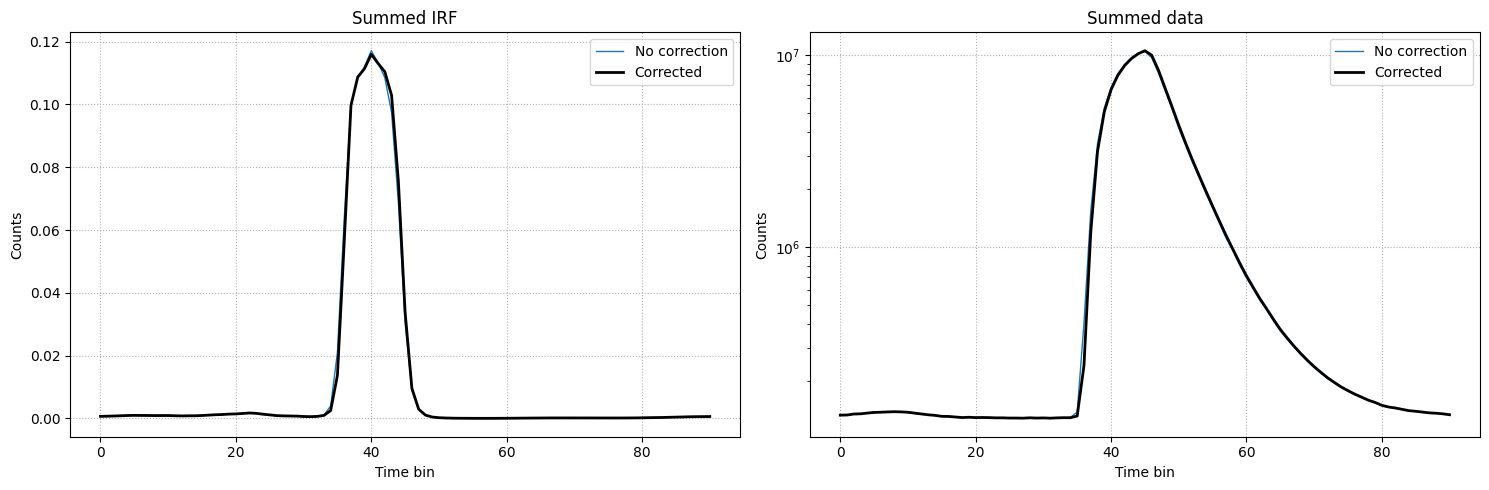

In [21]:
graph.plot_channel_skew_correction(
    irf_no_alignment=irf_summed_no_alignment,
    irf_aligned=irf_summed,
    data_no_alignment=data_summed_no_alignment,
    data_aligned=data_summed.sum(axis=(0, 1)),
)


In [22]:
with h5py.File(FILENAME_OUTPUT, "r") as hf:
    calibration = hf["calibration/results/spad"]

## Correct Phasors And Build Lifetime Maps


In [23]:
intensity_map = data_summed.sum(axis=-1)


with h5py.File(FILENAME_OUTPUT, "r") as hf:
    calibration = hf["calibration/results/spad"]
    tau_reference_ns= calibration["fit/tau_reference_ns"][:]

tau_reference_ns_median = np.median(tau_reference_ns)
print(f"Reference lifetime (median): {tau_reference_ns_median:.4f} ns")

if REFERENCE_TYPE == 'ref':
    # Theoretical phasor of the monoexponential reference sample
    omega = 2 * np.pi * laser_frequency_mhz * 1e6          # rad/s
    tau_ref_s = tau_reference_ns_median * 1e-9  # s
    ref_phasor_theoretical = 1.0 / (1.0 - 1j * omega * tau_ref_s)

    # The system response = measured_ref / theoretical_ref
    correction = ref_phasor / ref_phasor_theoretical

    print(f"Ref phasor measured:  {ref_phasor:.6f} \t mag. {np.abs(ref_phasor):.6f} @ {np.angle(ref_phasor, deg=True):.2f}°")
    print(f"Ref phasor theoretical:   {ref_phasor_theoretical:.6f} \t mag. {np.abs(ref_phasor_theoretical):.6f} @ {np.angle(ref_phasor_theoretical, deg=True):.2f}°")

else:  # REFERENCE_TYPE == 'irf'
    correction = irf_phasor
    
    #if  'complex' == "phase_only":
    #    irf_correction = irf_phasor / abs(irf_phasor)
    #else:
    #    irf_correction = irf_phasor

print(f"Correction factor:    {correction:.6f} \t mag. {np.abs(correction):.6f} @ {np.angle(correction, deg=True):.2f}°")

phasor_map = h5_dataset_phasor_pix / correction
tau_m_map = flim.calculate_tau_m(phasor_map, dfd_freq=laser_frequency_mhz * 1e6) * 1e9
tau_phi_map = flim.calculate_tau_phi(phasor_map, dfd_freq=laser_frequency_mhz * 1e6) * 1e9
lifetime_map = tau_m_map

threshold = 0.05
thresholded_phasor_map = flim.threshold_phasor(intensity_map, phasor_map, threshold)
thresholded_intensity_map = flim.threshold_intensity(intensity_map, threshold)
thresholded_tau_map, _, lifetime_mask = graph.threshold_lifetime_map(
    lifetime_map,
    intensity=intensity_map,
    threshold=threshold,
)

print("IRF phasor:", irf_phasor)
print("thresholded pixels:", thresholded_tau_map.size)


Reference lifetime (median): 5.4908 ns
Ref phasor measured:  -0.444113-0.300768j 	 mag. 0.536374 @ -145.89°
Ref phasor theoretical:   0.344308+0.475142j 	 mag. 0.586778 @ 54.07°
Correction factor:    -0.859169+0.312104j 	 mag. 0.914101 @ 160.04°
IRF phasor: (-0.8664612873709885+0.35314336980616107j)
thresholded pixels: 253698


/home/mdonato/myDev/FLIM/BrightEyes-Flim/src/brighteyes_flism/tools_phasor.py:603: RuntimeWarning: invalid value encountered in sqrt
  tau_m = np.sqrt((1. / (m ** 2)) - 1) / (2 * np.pi * dfd_freq)


Text(0.5, 1.0, 'Corrected phasor distribution')

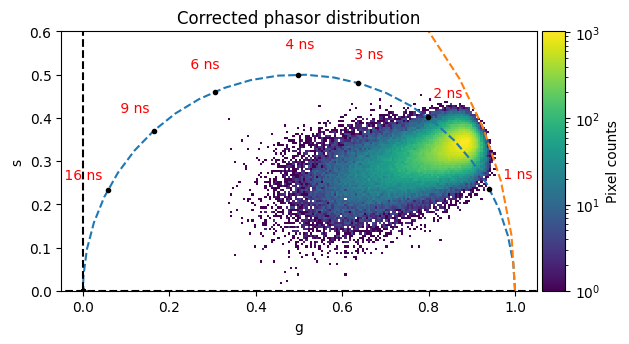

In [24]:
fig, ax = flim.plot_phasor(
    thresholded_phasor_map,
    quadrant="first",
    bins_2dplot=400,
    cmap="viridis",
    dfd_freq=laser_frequency_mhz * 1e6,
)
ax.set_title("Corrected phasor distribution")


## Tau-M / Tau-Phi Comparison


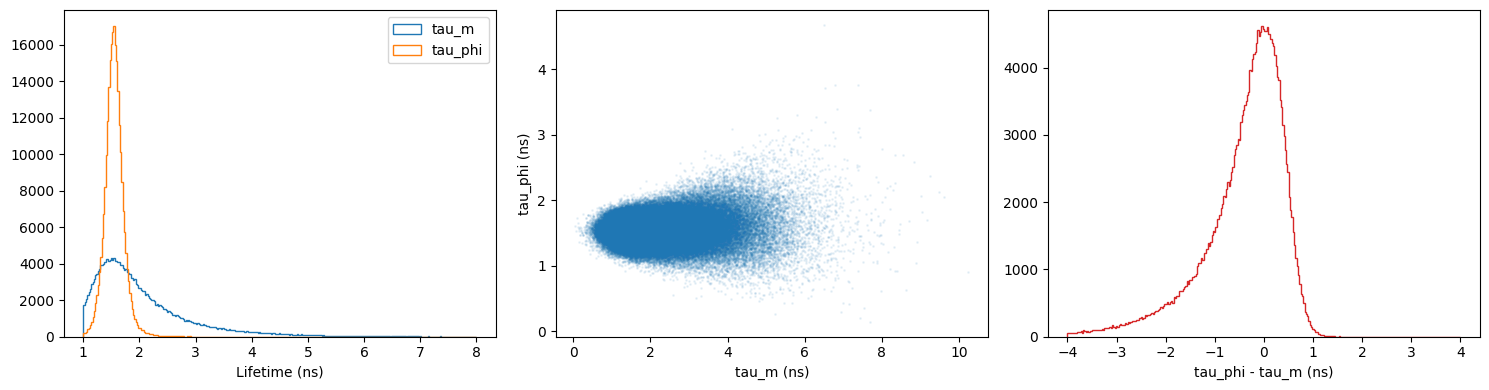

In [25]:
tau_compare_mask = (
    np.isfinite(tau_m_map)
    & np.isfinite(tau_phi_map)
    & np.isfinite(intensity_map)
    & (intensity_map > threshold * np.nanmax(intensity_map))
)

tau_m_compare = tau_m_map[tau_compare_mask]
tau_phi_compare = tau_phi_map[tau_compare_mask]
tau_diff_compare = tau_phi_compare - tau_m_compare

fig, axs = plt.subplots(1, 3, figsize=(15, 4))
axs[0].hist(tau_m_compare, bins=300, range=(1, 8), histtype="step", label="tau_m")
axs[0].hist(tau_phi_compare, bins=300, range=(1, 8), histtype="step", label="tau_phi")
axs[0].set_xlabel("Lifetime (ns)")
axs[0].legend()
axs[1].scatter(tau_m_compare, tau_phi_compare, s=1, alpha=0.08)
axs[1].set_xlabel("tau_m (ns)")
axs[1].set_ylabel("tau_phi (ns)")
axs[2].hist(tau_diff_compare, bins=300, range=(-4, 4), histtype="step", color="tab:red")
axs[2].set_xlabel("tau_phi - tau_m (ns)")
fig.tight_layout()


## Lifetime Visualization


/home/mdonato/myDev/FLIM/BrightEyes-ISM/src/brighteyes_ism/analysis/Graph_lib.py:687: RuntimeWarning: invalid value encountered in cast
  idx = (np.floor((variable - self.var_bounds[0]) / (self.var_bounds[1] - self.var_bounds[0]) * N)).astype(int)
/home/mdonato/myDev/FLIM/BrightEyes-ISM/src/brighteyes_ism/analysis/Graph_lib.py:807: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/home/mdonato/myDev/FLIM/BrightEyes-Flim/src/brighteyes_flism/graph_tools.py:727: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


(<Figure size 1300x600 with 3 Axes>,
 (<Axes: title={'center': 'Lifetime map'}>,
  <Axes: title={'center': 'Thresholded lifetime histogram'}, xlabel='Lifetime (ns)', ylabel='Pixel counts'>))

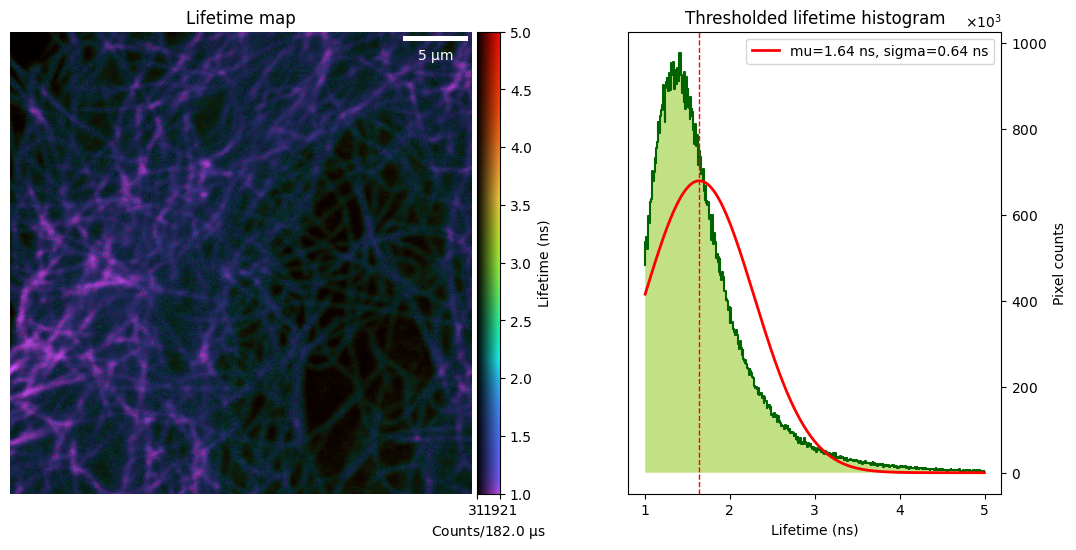

In [26]:
graph.plot_lifetime_summary(
    intensity=intensity_map,
    lifetime=lifetime_map,
    pxsize=pixel_size_x_um,
    pxdwelltime=pxdwelltime,
    lifetime_bounds=[1, 5],
    crop=30,
    threshold=threshold,
    bins=500,
    colormap="turbo",
    weighted_histogram=True,
)


/home/mdonato/myDev/FLIM/BrightEyes-Flim/src/brighteyes_flism/tools_phasor.py:1098: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/home/mdonato/myDev/FLIM/BrightEyes-Flim/src/brighteyes_flism/graph_tools.py:807: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


(<Figure size 900x1800 with 5 Axes>,
 (<Axes: title={'center': 'Linear hue axis'}>,
  <Axes: title={'center': 'Equalized hue axis (strength=4.0, bins=4096)'}>,
  <Axes: title={'center': 'Thresholded lifetime histogram'}, xlabel='Lifetime (ns)', ylabel='Pixel counts'>))

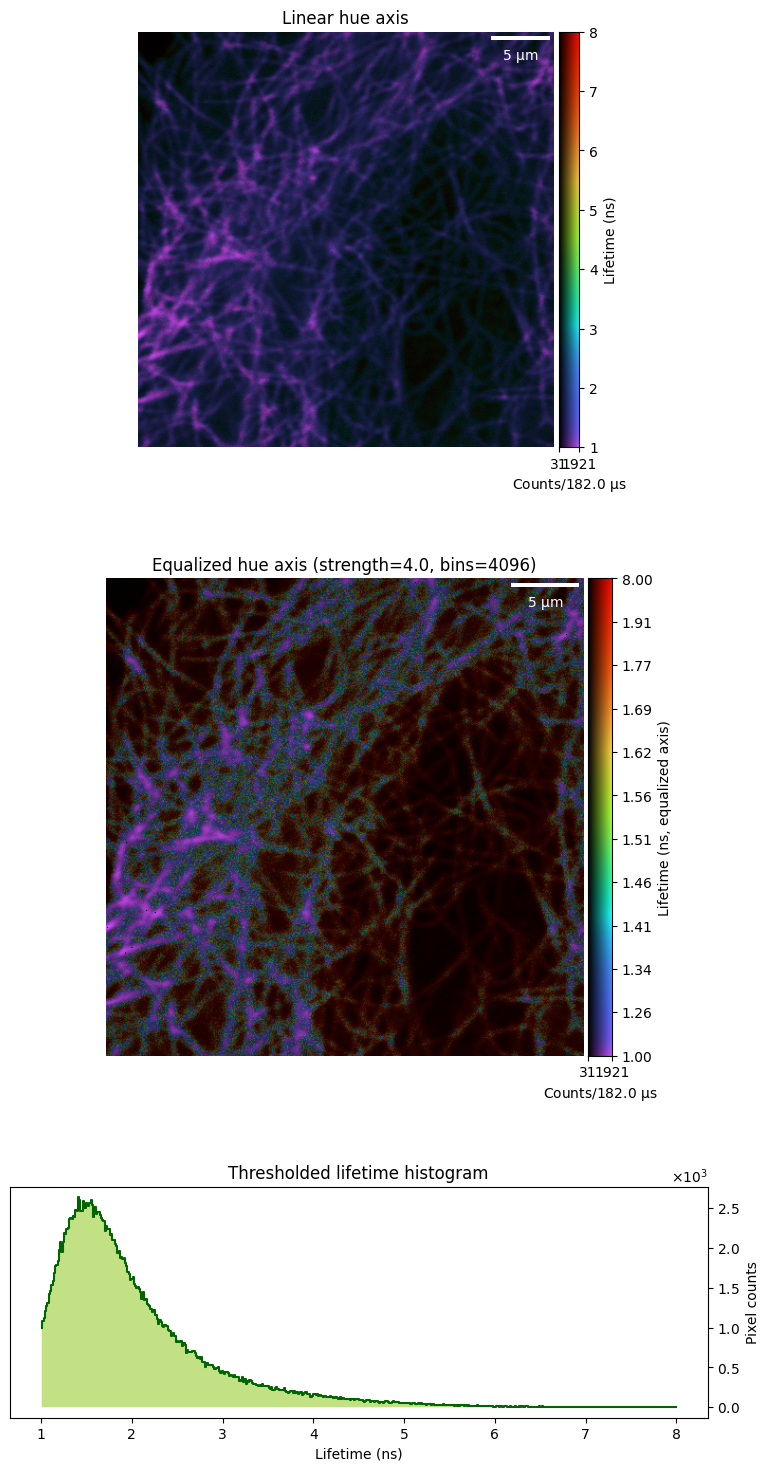

In [27]:
graph.plot_equalized_lifetime_summary(
    intensity=intensity_map,
    lifetime=lifetime_map,
    pxsize=pixel_size_x_um,
    pxdwelltime=pxdwelltime,
    lifetime_bounds=[1.0, 8.0],
    crop=30,
    threshold=threshold,
    bins=500,
    colormap="turbo",
    equalization_reference=thresholded_tau_map,
    equalization_strength=4.0,
    equalization_bins=4096,
    colorbar_ticks=12,
)


## Optional Export


In [28]:
if FILENAME_OUTPUT is not None:
    phasor_source_path = PIPELINE_H5 if "PIPELINE_H5" in globals() else FILENAME_OUTPUT
    phasor_mode = "append"
    phasor_output_path = None
    common_attrs = {
        "source_data_path": f"/raw/{CALIBRATION_PRODUCT}",
        "source_calibration_path": f"/calibration/results/{CALIBRATION_PRODUCT}",
        "source_metadata_path": "/raw/metadata",
        "source_axes_path": "/raw/axes",
        "time_axis_source": "/raw/axes/digital_time_ns",
        "time_bin_ns": laser_period_ns / nbin,
        "laser_frequency_mhz": laser_frequency_mhz,
        "laser_period_ns": laser_period_ns,
    }
    products = [
        H5OutputProduct("intensity", intensity_map, attrs={**common_attrs, "data_role": "integrated_intensity", "axis_order": "y,x"}),
        H5OutputProduct("phasor_real", np.real(phasor_map), attrs={**common_attrs, "data_role": "phasor_real", "axis_order": "y,x"}),
        H5OutputProduct("phasor_imag", np.imag(phasor_map), attrs={**common_attrs, "data_role": "phasor_imag", "axis_order": "y,x"}),
        H5OutputProduct("tau_m_ns", tau_m_map, attrs={**common_attrs, "data_role": "tau_m", "units": "ns", "axis_order": "y,x"}),
        H5OutputProduct("tau_phi_ns", tau_phi_map, attrs={**common_attrs, "data_role": "tau_phi", "units": "ns", "axis_order": "y,x"}),
        H5OutputProduct("tau_ns", lifetime_map, attrs={**common_attrs, "data_role": "primary_lifetime", "units": "ns", "axis_order": "y,x"}),
        H5OutputProduct("decay_sum", data_summed, attrs={**common_attrs, "data_role": "channel_summed_decay", "axis_order": "y,x,time_bin"}),
        H5OutputProduct("irf", irf_summed, attrs={**common_attrs, "data_role": "channel_summed_irf", "axis_order": "time_bin"}),
        H5OutputProduct("ref", ref_summed, attrs={**common_attrs, "data_role": "channel_summed_reference", "axis_order": "time_bin"}),
        H5OutputProduct("irf_phasor_real", np.asarray(np.real(irf_phasor)), attrs={**common_attrs, "data_role": "irf_phasor_real"}),
        H5OutputProduct("irf_phasor_imag", np.asarray(np.imag(irf_phasor)), attrs={**common_attrs, "data_role": "irf_phasor_imag"}),
        H5OutputProduct("ref_phasor_real", np.asarray(np.real(ref_phasor)), attrs={**common_attrs, "data_role": "ref_phasor_real"}),
        H5OutputProduct("ref_phasor_imag", np.asarray(np.imag(ref_phasor)), attrs={**common_attrs, "data_role": "ref_phasor_imag"}),
        H5OutputProduct("corr_real", np.asarray(np.real(correction)), attrs={**common_attrs, "data_role": "phasor_correction_real"}),
        H5OutputProduct("corr_imag", np.asarray(np.imag(correction)), attrs={**common_attrs, "data_role": "phasor_correction_imag"}),
    ]
    target_path, output_run_id = write_h5_output_run(
        phasor_source_path,
        "phasor",
        products,
        mode=phasor_mode,
        output_path=phasor_output_path,
        output_key_overwrite=True,
        output_type="image_tool",
        tool_name="Phasor lifetime",
        algorithm_name="phasor_correction",
        parameters={
            "reference_type": REFERENCE_TYPE,
            "tau_ref_input_ns": TAU_REF,
            "tau_ref_used_ns": tau_reference_ns_median,
            "threshold_fraction": threshold,
            "data_key": DATA_KEY,
            "calibration_product": CALIBRATION_PRODUCT,
        },
        metadata={
            **common_attrs,
            "pixel_size_x_um": pixel_size_x_um,
            "pixel_dwell_time_us": pxdwelltime,
            "output_ny": intensity_map.shape[0],
            "output_nx": intensity_map.shape[1],
            "output_time_bins": data_summed.shape[-1],
            "selected_channel_count": data_input.shape[-1],
            "channel_aggregation": "sum_channels_with_skew_correction",
        },
        axes=[H5OutputProduct("time_ns", np.arange(nbin, dtype=float) * laser_period_ns / nbin, attrs={"axis": "time", "units": "ns"})],
        attrs={
            **common_attrs,
            "input_axis_order": "repetition,z,y,x,time_bin,detector_channel",
            "output_axis_order": "y,x",
            "output_data_path": "/output/{run_id}/products/tau_ns",
        },
        set_default=True,
    )
    PIPELINE_H5 = target_path
    print(f"Saved {output_run_id} -> {target_path}")
else:
    print("Export skipped (FILENAME_OUTPUT = None).")


Saved phasor -> /mnt/DATA/Mixed Data/Giuse2/Test_01_small_DFD_phasor_workflow.h5


In [30]:
show_h5_structure_html(FILENAME_OUTPUT)


'<script>\n(function () {\n  // Expand / collapse ALL groups in the widget\n  function h5All(widgetId, open) {\n    var root = document.getElementById(widgetId);\n    if (!root) return;\n    root.querySelectorAll(\'details.h5-branch\').forEach(function(d) {\n      d.open = open;\n    });\n  }\n\n  // Expand / collapse all groups at a specific depth inside a widget\n  function h5LevelToggle(widgetId, depth, open, btn) {\n    // Stop the click from toggling the parent <details>\n    if (btn) { btn.closest(\'details\') && (event || window.event) && (event || window.event).stopPropagation(); }\n    var root = document.getElementById(widgetId);\n    if (!root) return;\n    root.querySelectorAll(\'li.h5-li-group[data-depth="\' + depth + \'"]\').forEach(function(li) {\n      var det = li.querySelector(\':scope > details.h5-branch\');\n      if (det) det.open = open;\n    });\n  }\n\n  // Expose globally so onclick= attributes work\n  window.h5All = h5All;\n  window.h5LevelToggle = h5LevelTogg